In [48]:
from torchvision.transforms import ToTensor
%matplotlib inline
import torch
import torchvision
from torch.utils import data
from torchvision import transforms
from d2l import torch as d2l

In [49]:
trans = transforms.ToTensor() # 数据预处理
mnist_train = torchvision.datasets.FashionMNIST(root='../data', train=True, transform=trans, download=True)
mnist_test = torchvision.datasets.FashionMNIST(root='../data', train=False, transform=trans, download=True)
len(mnist_train), len(mnist_test)

(60000, 10000)

In [50]:
mnist_train[0][0].shape

torch.Size([1, 28, 28])

In [61]:
def get_fashion_mnist_labels(labels): # 返回FashionMnist数据集的文本标签
    text_labels = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat', 'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']
    return [text_labels[int(i)] for i in labels]

def show_images(imgs, num_rows, num_cols, titles=None, scales=1.5): # 纯画图
    figsize = (num_cols * scales, num_rows * scales)
    _, axes = d2l.plt.subplots(num_rows, num_cols, figsize=figsize)
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        if torch.is_tensor(img):
            ax.imshow(img.numpy())
        else:
            ax.imshow(img)

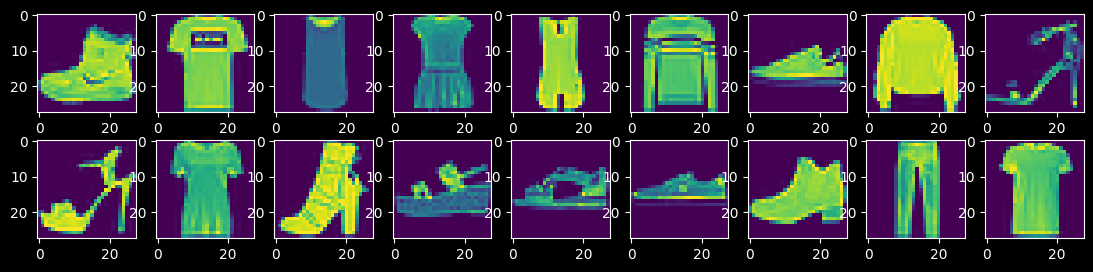

In [62]:
from torch.utils.data import DataLoader
X, y = next(iter(DataLoader(mnist_train, batch_size=18)))
show_images(X.reshape(18, 28, 28), 2, 9, titles=get_fashion_mnist_labels(y))

In [67]:
batch_size = 256
train_iter = DataLoader(mnist_train, batch_size, shuffle=True, num_workers=4)
timer = d2l.Timer()
for X, y in train_iter:
    continue
print(f'{timer.stop():.2f}sec')

4.39sec


In [ ]:
def load_data_fashion_mnist(batch_size, resize=None):
    # 数据预处理
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    # 获取数据集对象
    mnist_train = torchvision.datasets.FashionMNIST(root='../data', train=True, transforms=trans, download=True)
    mnist_test = torchvision.datasets.FashionMNIST(root='../data', train=True, transforms=trans, download=True)
    # 封装为DataLoader并返回
    return data.DataLoader(mnist_train, batch_size, shuffle=True, num_workers=4), data.DataLoader(mnist_test, batch_size,shuffle=True, num_workers=4)
